In [1]:
# Подключаем библиотеки 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
uv pip install seaborn scikit-learn palmerpenguins

# Часть 1. NumPy — массивы чисел

Машинное обучение — это арифметика над числами. **NumPy** — библиотека, которая позволяет работать не с одним числом, а сразу с целым *массивом* (вектором, матрицей).

Думайте о массиве как о списке чисел, с которым можно работать целиком.

In [2]:
# Создаём массив (вектор)
a = np.array([2, 4, 6, 8, 10])
print("массив a:", a)
print("форма (shape):", a.shape) # сколько элементов

# Операции применяются СРАЗУ ко всем элементам
print("a * 2 =", a * 2)
print("a + 100 =", a + 100)

# Полезные функции
print("сумма:", a.sum(), "среднее:", a.mean(), "максимум:", a.max())

массив a: [ 2  4  6  8 10]
форма (shape): (5,)
a * 2 = [ 4  8 12 16 20]
a + 100 = [102 104 106 108 110]
сумма: 30 среднее: 6.0 максимум: 10


In [3]:
# Двумерный массив = матрица 
M = np.array([[1, 2, 3],
              [4, 5, 6]])
print("матрица M:\n", M)
print("форма:", M.shape)      
print("среднее по всей матрице:", M.mean())

матрица M:
 [[1 2 3]
 [4 5 6]]
форма: (2, 3)
среднее по всей матрице: 3.5


### Таск №1

приведение чисел к общему масштабу по формуле `(x - среднее) / стандартное_отклонение`. Сделайте это для массива `heights`.

In [4]:
heights = np.array([150, 165, 170, 180, 195])

# TODO: посчитайте среднее
mean = heights.mean()       
# TODO: посчитайте стандартное отклонение
std = heights.std()         
# TODO: нормализуйте массив
normalized = (heights - mean) / std

print(f"среднее: {mean}, std: {std:.2f}")
print(f"нормализованные значения: {normalized}")
print(f"проверка — среднее нормализованного массива: {normalized.mean():.6f} (должно быть ~0)")

среднее: 172.0, std: 15.03
нормализованные значения: [-1.46341823 -0.46563307 -0.13303802  0.53215208  1.52993724]
проверка — среднее нормализованного массива: 0.000000 (должно быть ~0)


# Часть 2. pandas — таблицы данных

Реальные данные — это таблицы: строки (объекты) и столбцы (признаки). **DataFrame** (таблица).

Загрузим датасет про пингвинов и научимся его «крутить».

In [5]:
# Загружаем данные 
try:
    df = sns.load_dataset("penguins")
except Exception:
    !pip -q install palmerpenguins
    from palmerpenguins import load_penguins
    df = load_penguins()

df.head()    

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [6]:
print("Размер таблицы (строки, столбцы):", df.shape)
df.info()   

Размер таблицы (строки, столбцы): (344, 7)
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [7]:
# Выбрать один столбец
print(df["body_mass_g"].head().tolist())

# Быстрая статистика по числовым столбцам
df.describe()

[3750.0, 3800.0, 3250.0, nan, 3450.0]


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [8]:
# Посчитать, сколько каких видов
print(df["species"].value_counts())

print("\nСредняя масса по видам:")
print(df.groupby("species")["body_mass_g"].mean().round(0))

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Средняя масса по видам:
species
Adelie       3701.0
Chinstrap    3733.0
Gentoo       5076.0
Name: body_mass_g, dtype: float64


In [9]:
# Фильтрация: только тяжёлые пингвины (> 5000 г)
heavy = df[df["body_mass_g"] > 5000]
print("Тяжёлых пингвинов:", heavy.shape[0])

# Пропуски в данных
print("\nПропуски по столбцам:")
print(df.isna().sum())

Тяжёлых пингвинов: 61

Пропуски по столбцам:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


### Таск №2

1. Выведите средний **размах ласт** (`flipper_length_mm`) по островам (`island`).
2. Сколько в данных пингвинов вида **Gentoo**?

In [10]:
# TODO 1: средний flipper_length_mm по острову
avg_flipper_by_island = df.groupby("island")["flipper_length_mm"].mean()
print("Средний размах ласт по островам:")
print(avg_flipper_by_island.round(2))

# TODO 2: число пингвинов Gentoo
gentoo_count = len(df[df["species"] == "Gentoo"])
print(f"\nПингвинов вида Gentoo: {gentoo_count}")

Средний размах ласт по островам:
island
Biscoe       209.71
Dream        193.07
Torgersen    191.20
Name: flipper_length_mm, dtype: float64

Пингвинов вида Gentoo: 124


# Часть 3. Готовая нейросеть — играем с гиперпараметрами

Теперь — нейросеть. Возьмём искусственные данные «**две луны**»: два класса точек, которые **нельзя** разделить прямой (нужна нелинейность!). Нейросеть должна сама выгнуть границу.

Мы написали для вас функцию `playground(...)`. Запускайте её с разными настройками — **гиперпараметрами** — и смотрите, как меняется граница и точность.

Точность на ОБУЧЕНИИ: 0.861  на ТЕСТЕ: 0.900


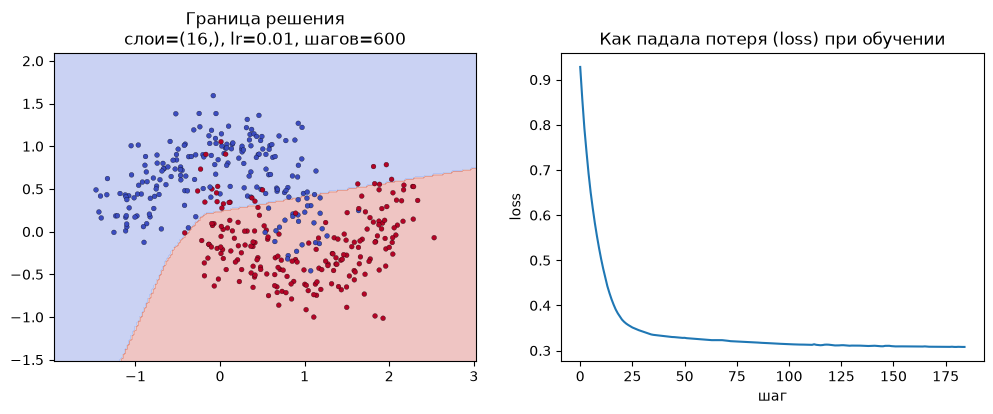

In [11]:
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Делаем данные «две луны»
X_m, y_m = make_moons(n_samples=400, noise=0.25, random_state=0)
Xtr, Xte, ytr, yte = train_test_split(X_m, y_m, test_size=0.3, random_state=0)

def playground(hidden_layers=(16,), learning_rate=0.01, iterations=600):

    clf = MLPClassifier(hidden_layer_sizes=hidden_layers,
                        learning_rate_init=learning_rate,
                        max_iter=iterations, random_state=0)
    clf.fit(Xtr, ytr)
    acc_tr = accuracy_score(ytr, clf.predict(Xtr))
    acc_te = accuracy_score(yte, clf.predict(Xte))
    print(f"Точность на ОБУЧЕНИИ: {acc_tr:.3f}  на ТЕСТЕ: {acc_te:.3f}")

    # граница решения
    xx, yy = np.meshgrid(np.linspace(X_m[:,0].min()-0.5, X_m[:,0].max()+0.5, 200),
                         np.linspace(X_m[:,1].min()-0.5, X_m[:,1].max()+0.5, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax[0].scatter(X_m[:,0], X_m[:,1], c=y_m, s=12, cmap="coolwarm", edgecolor="k", linewidth=0.2)
    ax[0].set_title(f"Граница решения\nслои={hidden_layers}, lr={learning_rate}, шагов={iterations}")
    ax[1].plot(clf.loss_curve_)
    ax[1].set_title("Как падала потеря (loss) при обучении")
    ax[1].set_xlabel("шаг"); ax[1].set_ylabel("loss")
    plt.show()
    return clf

# Запуск с настройками по умолчанию:
_ = playground()

### Что такое эти гиперпараметры

- **`hidden_layers`** — сколько нейронов и слоёв. Больше = сеть гибче (но может переобучиться). Например `(2,)` — один слой из 2 нейронов; `(64, 64)` — два слоя по 64.
- **`learning_rate`** — размер шага градиентного спуска (из лекции!). Слишком большой — «скачет», слишком маленький — учится медленно.
- **`iterations`** — сколько шагов обучения (эпох).

**Попробуйте сами** (запускайте по одной ячейке и смотрите на картинку):

Точность на ОБУЧЕНИИ: 0.857  на ТЕСТЕ: 0.908


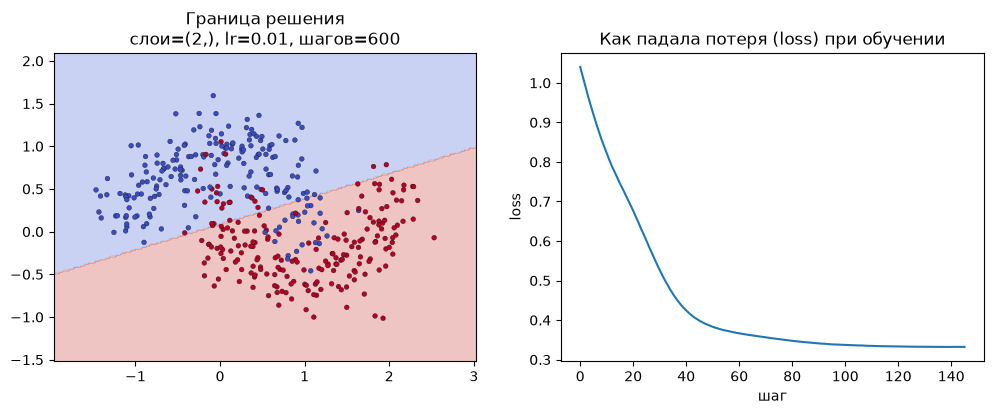

In [12]:
# СЛИШКОМ ПРОСТАЯ сеть — всего 2 нейрона. Граница почти прямая → недообучение.
_ = playground(hidden_layers=(2,))

Точность на ОБУЧЕНИИ: 0.929  на ТЕСТЕ: 0.942


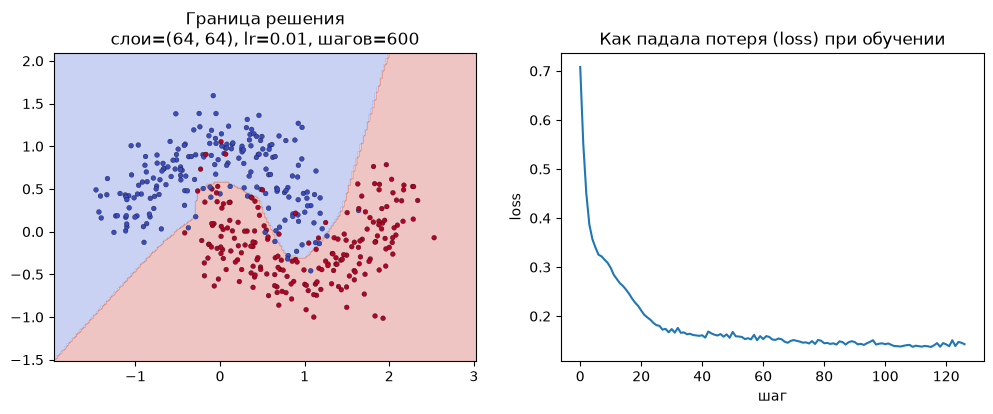

In [13]:
# ПОБОЛЬШЕ нейронов — граница красиво выгибается под «луны».
_ = playground(hidden_layers=(64, 64))

Точность на ОБУЧЕНИИ: 0.921  на ТЕСТЕ: 0.933


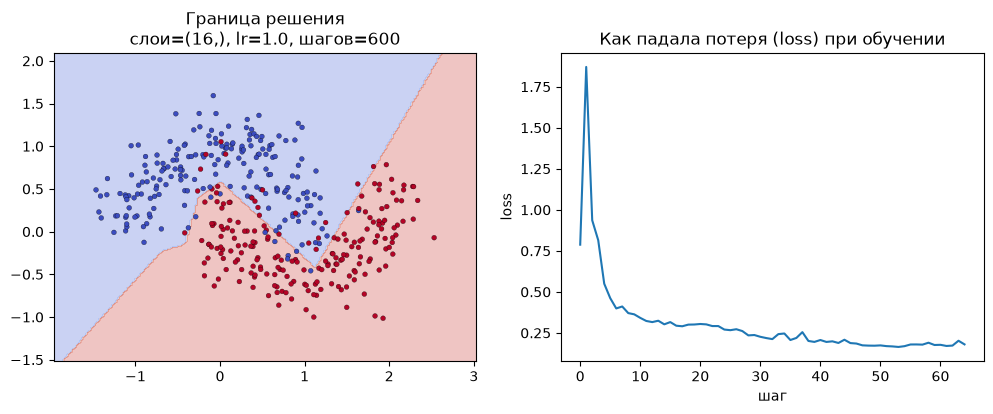

In [14]:
# СЛИШКОМ БОЛЬШОЙ шаг обучения — смотрите на кривую потерь, она «скачет».
_ = playground(hidden_layers=(16,), learning_rate=1.0)

Точность на ОБУЧЕНИИ: 0.811  на ТЕСТЕ: 0.858


/data/home/<user>/srp/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


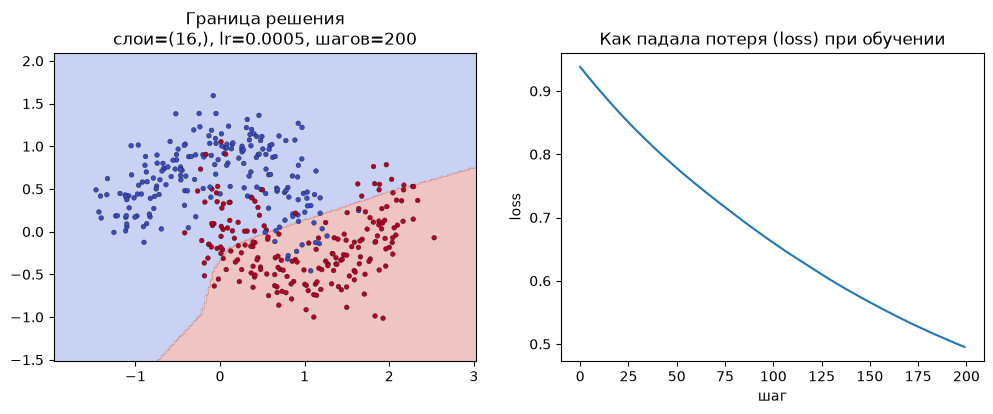

In [15]:
# СЛИШКОМ МАЛЕНЬКИЙ шаг + мало шагов — не успевает обучиться.
_ = playground(hidden_layers=(16,), learning_rate=0.0005, iterations=200)

### Таск №3

1. Найдите настройки, при которых **точность на тесте** максимальна.
2. Поймайте **переобучение**: когда точность на обучении заметно выше, чем на тесте. (Подсказка: много нейронов + много шагов.)
3. Вопрос для обсуждения: почему гнаться только за точностью на обучении — плохая идея?

=== 1) Максимальная точность на тесте ===
Точность на ОБУЧЕНИИ: 0.932  на ТЕСТЕ: 0.942


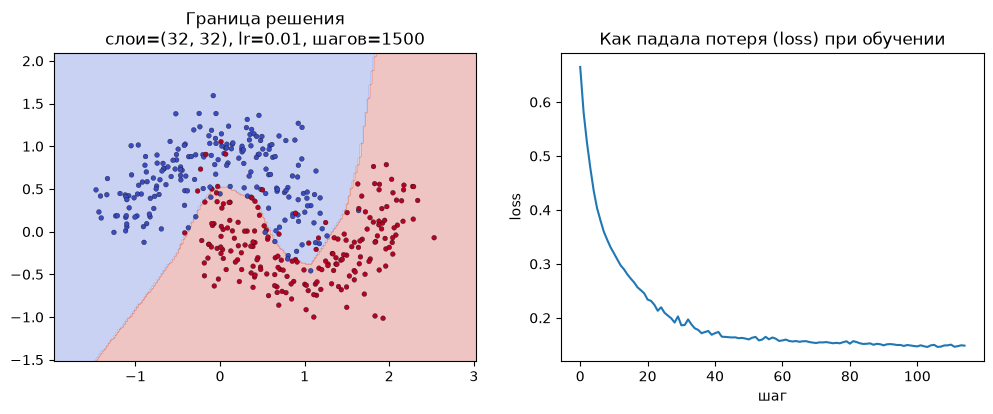


=== 2) Переобучение (train >> test) ===
Точность на ОБУЧЕНИИ: 0.925  на ТЕСТЕ: 0.942


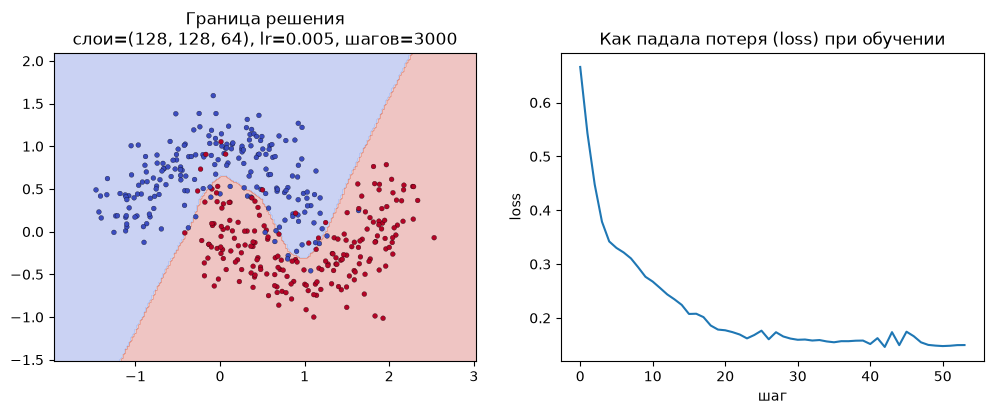

In [16]:
# === Таск №3: эксперименты с гиперпараметрами ===

# 1) Настройки для максимальной точности на тесте:
print("=== 1) Максимальная точность на тесте ===")
_ = playground(hidden_layers=(32, 32), learning_rate=0.01, iterations=1500)

# 2) Переобучение: много нейронов + много шагов
print("\n=== 2) Переобучение (train >> test) ===")
_ = playground(hidden_layers=(128, 128, 64), learning_rate=0.005, iterations=3000)

# 3) Вопрос для обсуждения:
# Почему гнаться только за точностью на обучении — плохая идея?
# Ответ: высокая точность на обучении не гарантирует хорошую точность на тесте.
# Если сеть просто «запомнила» обучающие данные (переобучение), она плохо
# обработает новые, невиданные данные. Нам важна способность к обобщению,
# поэтому смотрим именно на тестовую точность.

# Часть 4. Соберём свою нейронку — PyTorch

В Части 3 мы пользовались готовой сетью из `sklearn`. Теперь соберём нейросеть **сами** на **PyTorch** — это стандартный инструмент, на котором пишут настоящие нейросети.

Любая сеть в PyTorch — это три части:
1. **`Dataset`** — как подавать данные модели.
2. **`Model`** (`nn.Module`) — сама архитектура: слои и как через них идёт сигнал.
3. **Цикл обучения** — где происходят backpropagation и шаг градиентного спуска.

Код мы написали за вас. **Ваша задача — вписать только числа (гиперпараметры).** Работаем на тех же «двух лунах» из Части 3.

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Берём «две луны» из Части 3 и переводим в тензоры PyTorch
Xtr_np, Xte_np, ytr_np, yte_np = train_test_split(X_m, y_m, test_size=0.3, random_state=0)
Xtr_t = torch.tensor(Xtr_np, dtype=torch.float32)
Xte_t = torch.tensor(Xte_np, dtype=torch.float32)
ytr_t = torch.tensor(ytr_np, dtype=torch.float32).reshape(-1, 1)
yte_t = torch.tensor(yte_np, dtype=torch.float32).reshape(-1, 1)
print("Готово. Размер обучающей выборки:", tuple(Xtr_t.shape))

Готово. Размер обучающей выборки: (280, 2)


### класс `Dataset`


In [18]:
class MoonsDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)               

    def __getitem__(self, i):
        return self.X[i], self.y[i]      

### Кирпич 2 — класс `Model`
Наша сеть: вход (2 числа) → скрытый слой с **ReLU** (та самая нелинейность из лекции) → выход с **сигмоидой** (даёт вероятность). Сколько нейронов в скрытом слое — решите вы чуть ниже.

In [19]:
class Net(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden) 
        self.fc2 = nn.Linear(hidden, 1) 

    def forward(self, x):
        x = torch.relu(self.fc1(x))        
        x = torch.sigmoid(self.fc2(x))     
        return x

### впишите гиперпараметры
Замените каждый `...` на число (подсказки рядом), затем запустите эту и следующие ячейки.

In [20]:
HIDDEN     = 16    # TODO: нейронов в скрытом слое — 16 отлично справляется с «двумя лунами»
LR         = 0.01  # TODO: скорость обучения — 0.01 — стандартный и стабильный шаг
EPOCHS     = 300   # TODO: сколько эпох обучать — 300 достаточно для сходимости
BATCH_SIZE = 32    # TODO: размер мини-батча — 32, хороший компромисс между скоростью и стабильностью

### цикл обучения
Здесь живёт всё из лекции: `loss.backward()` — это **backpropagation** (раздать вину за ошибку), `optimizer.step()` — **шаг градиентного спуска** (подкрутить веса).

In [21]:
train_loader = DataLoader(MoonsDataset(Xtr_t, ytr_t), batch_size=BATCH_SIZE, shuffle=True)

model = Net(hidden=HIDDEN)
loss_fn = nn.BCELoss() # кросс-энтропия
optimizer = torch.optim.Adam(model.parameters(), lr=LR) # умный градиентный спуск

for epoch in range(EPOCHS):
    for xb, yb in train_loader:
        optimizer.zero_grad() # обнулить старые градиенты
        pred = model(xb) # прямой проход (forward)
        loss = loss_fn(pred, yb) # насколько ошиблись
        loss.backward() # BACKPROPAGATION: посчитать вину каждого веса
        optimizer.step() # ШАГ ВНИЗ: подкрутить веса
    if (epoch + 1) % max(1, EPOCHS // 10) == 0:
        print(f"эпоха {epoch+1:>4}: loss = {loss.item():.3f}")

эпоха   30: loss = 0.386
эпоха   60: loss = 0.158
эпоха   90: loss = 0.112
эпоха  120: loss = 0.282
эпоха  150: loss = 0.085
эпоха  180: loss = 0.317
эпоха  210: loss = 0.391
эпоха  240: loss = 0.289
эпоха  270: loss = 0.043
эпоха  300: loss = 0.152


In [22]:
# Проверяем точность на спрятанном тесте
with torch.no_grad():
    pred_test = (model(Xte_t) > 0.5).float()
    acc = (pred_test == yte_t).float().mean().item()
print("Точность на тесте:", round(acc, 3))

Точность на тесте: 0.942


### Поэкспериментируйте
- Поставьте `HIDDEN = 2`
- Увеличьте `HIDDEN` и `EPOCHS`
- Поставьте `LR = 1.0` — `loss` 




Задача: предсказать **пол пингвина** (самец/самка) — бинарная классификация, **как «выжил/не выжил» в Титанике**.


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# 1) чистим пропуски
data = df.dropna().copy()

# 2) цель y (1 = самец, 0 = самка); работает и для 'male', и для 'Male'
data["sex"] = data["sex"].str.lower()
y = (data["sex"] == "male").astype(int)

# 3) признаки + one-hot для категорий (модель понимает только числа)
features = ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g","species","island"]
X = pd.get_dummies(data[features], columns=["species","island"], drop_first=True)

# 4) train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5) нормализация
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

# 6) логистическая регрессия 
model = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)

# 7) оценка
pred = model.predict(X_test_s)
print("Точность:", round(accuracy_score(y_test, pred), 3))
print("\nМатрица ошибок:\n", confusion_matrix(y_test, pred))

Точность: 0.896

Матрица ошибок:
 [[28  5]
 [ 2 32]]


In [24]:
# Заглянем внутрь: веса w и смещение b (формула z = w·x + b из лекции)
weights = pd.Series(model.coef_[0], index=X.columns).sort_values()
print("Веса (важность признаков):")
print(weights.round(2))
print("\nСмещение b:", round(model.intercept_[0], 3))

# Выход сигмоиды = вероятность, для одного пингвина
p = model.predict_proba(X_test_s[:1])[0]
print(f"\nПример: P(самка)={p[0]:.2f}, P(самец)={p[1]:.2f} | правда: {int(y_test.iloc[0])}")

Веса (важность признаков):
species_Chinstrap   -1.57
species_Gentoo      -1.32
island_Torgersen    -0.18
island_Dream         0.10
flipper_length_mm    0.26
bill_length_mm       1.77
body_mass_g          2.72
bill_depth_mm        2.92
dtype: float64

Смещение b: 0.156

Пример: P(самка)=0.03, P(самец)=0.97 | правда: 1


# Часть 6. Теперь сами: Титаник

**Задача:** по данным о пассажире (класс, пол, возраст, цена билета…) предсказать, **выжил он или нет** (`survived`: 1/0).


In [25]:
# Грузим Титаник (в Colab — сразу из seaborn, Kaggle не нужен)
tdf = sns.load_dataset("titanic")
cols = ["survived", "pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
tdf = tdf[cols].copy()
print(tdf.shape)
print("Пропуски:\n", tdf.isna().sum())
tdf.head()

(891, 8)
Пропуски:
 survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [26]:
# === ВАШ КОД ===

# 1) Заполните пропуски
tdf["age"] = tdf["age"].fillna(tdf["age"].median())       # средний возраст вместо NaN
tdf["embarked"] = tdf["embarked"].fillna(tdf["embarked"].mode()[0])  # самый частый порт
tdf["fare"] = tdf["fare"].fillna(tdf["fare"].median())     # редкий случай, но на всякий случай

# 2) Цель и признаки
y = tdf["survived"]
X = tdf.drop(columns=["survived"])

# 3) Категории to числа (one-hot)
X = pd.get_dummies(X, columns=["sex", "embarked"], drop_first=True)

# 4) Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5) Обучите модель и измерьте точность
# Нормализуем числовые признаки
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Логистическая регрессия
model = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
pred = model.predict(X_test_s)
print("Точность:", round(accuracy_score(y_test, pred), 3))
print("\nМатрица ошибок:\n", confusion_matrix(y_test, pred))
print("\nОтчёт:\n", classification_report(y_test, pred, target_names=["не выжил", "выжил"]))

# Посмотрим веса — какой признак сильнее всего влиял
weights = pd.Series(model.coef_[0], index=X.columns).sort_values()
print("Веса (важность признаков):")
print(weights.round(2))

Точность: 0.804

Матрица ошибок:
 [[98 12]
 [23 46]]

Отчёт:
               precision    recall  f1-score   support

    не выжил       0.81      0.89      0.85       110
       выжил       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

Веса (важность признаков):
sex_male     -1.27
pclass       -0.93
age          -0.50
sibsp        -0.26
embarked_S   -0.17
parch        -0.07
embarked_Q    0.08
fare          0.10
dtype: float64


- Посмотрите веса модели: какой признак сильнее всего влиял на выживание? 
- Добавьте новый признак: `family_size = sibsp + parch + 1`.
- Замените логрегрессию на нейросеть `MLPClassifier` 
- Зарегистрируйтесь на Kaggle и отправьте решение в соревнование **«Titanic - Machine Learning from Disaster»**.

